# Strict AOG v39 Template Quality Diagnostics

This notebook adds the missing template-level diagnostics: usage, simplicity, and representativeness. It compares v38 and v39 because v38 has the best validation accuracy while v39 has the cleanest structural audit.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() and (candidate / 'experiments' / 'aog_v19_v23').exists():
            return candidate
    return start

ROOT = find_repo_root()
V38 = ROOT / 'experiments/aog_v19_v23/runs/strict_aog_v38_template_quality'
V39 = ROOT / 'experiments/aog_v19_v23/runs/strict_aog_v39_template_quality'
print('ROOT:', ROOT)
print('v38 exists:', V38.exists())
print('v39 exists:', V39.exists())

ROOT: /home/dfli/instance_slot_aog
v38 exists: True
v39 exists: True


## Class-Level Usage and Simplicity

`effective_templates_used` measures how many templates are actually used per class on validation examples. `mean_slots` and `mean_edges` measure simplicity. A good class should not need one very large template to cover most examples unless the class truly has one stable layout.


In [2]:
v38c = pd.read_csv(V38 / 'strict_aog_v38_template_quality_by_class.csv')
v39c = pd.read_csv(V39 / 'strict_aog_v39_template_quality_by_class.csv')
cols = ['class_name','accuracy','effective_templates_used','max_usage_frac','mean_slots','mean_edges','mean_position_std','num_low_usage_templates','num_high_use_complex_templates','num_high_degree_templates']
display(Markdown('### v38'))
display(v38c[cols])
display(Markdown('### v39'))
display(v39c[cols])

### v38

,class_name,accuracy,effective_templates_used,max_usage_frac,mean_slots,mean_edges,mean_position_std,num_low_usage_templates,num_high_use_complex_templates,num_high_degree_templates
0,aeroplane,0.800000,1.995557,0.533333,8.333333,15.666667,0.149385,1,1,3
1,bicycle,0.937500,1.996095,0.531250,5.000000,5.333333,0.151678,1,0,1
2,biped,0.968504,2.903527,0.456693,5.666667,11.666667,0.152611,0,0,2
3,bird,0.965812,1.986432,0.752137,6.000000,8.666667,0.149114,0,0,2
4,boat,1.000000,1.000000,1.000000,3.000000,2.000000,0.137493,2,0,0
5,bottle,0.916667,1.000000,1.000000,2.000000,1.000000,0.154862,0,0,0
6,car,1.000000,2.436260,0.526316,5.333333,9.333333,0.145709,0,0,2
7,fish,0.915493,2.945456,0.408451,5.333333,10.000000,0.172647,0,0,2
8,quadruped,0.980114,1.613467,0.815341,4.333333,8.666667,0.162026,1,0,2
9,reptile,0.967391,1.563531,0.880435,4.666667,9.666667,0.167547,1,0,2


### v39

,class_name,accuracy,effective_templates_used,max_usage_frac,mean_slots,mean_edges,mean_position_std,num_low_usage_templates,num_high_use_complex_templates,num_high_degree_templates
0,aeroplane,0.733333,1.995557,0.533333,8.333333,11.000000,0.149385,1,1,0
1,bicycle,0.937500,1.996095,0.531250,5.000000,4.666667,0.151678,1,0,0
2,biped,0.968504,2.902201,0.456693,5.666667,6.666667,0.152611,0,0,0
3,bird,0.965812,1.915065,0.777778,6.000000,6.333333,0.149114,0,0,0
4,boat,1.000000,1.000000,1.000000,3.000000,2.000000,0.137493,2,0,0
5,bottle,0.916667,1.000000,1.000000,2.000000,1.000000,0.154862,0,0,0
6,car,1.000000,2.203189,0.543860,5.333333,6.666667,0.145709,1,0,0
7,fish,0.915493,2.945456,0.408451,5.333333,7.333333,0.172647,0,0,0
8,quadruped,0.980114,1.620245,0.812500,4.333333,5.333333,0.162026,1,0,0
9,reptile,0.967391,1.563531,0.880435,4.666667,5.666667,0.167547,1,0,0


## Template-Level Flags

Flags include low-use templates, high-use complex templates, high-degree templates, and rigid high-use layouts.


In [3]:
v39t = pd.read_csv(V39 / 'strict_aog_v39_template_quality_by_template.csv')
flagged = v39t[v39t['quality_flags'].fillna('') != '']
display(flagged[['class_name','template_id','true_usage_frac','accuracy_when_true_template','num_slots','num_edges','max_degree','position_std_mean','quality_flags']])

,class_name,template_id,true_usage_frac,accuracy_when_true_template,num_slots,num_edges,max_degree,position_std_mean,quality_flags
0,aeroplane,0,0.533333,1.000000,9,12,3,0.160465,many_slots;high_use_complex_template
2,aeroplane,2,0.000000,NaN,10,13,3,0.139008,low_usage;many_slots
5,bicycle,2,0.000000,NaN,6,7,3,0.156237,low_usage
13,boat,1,0.000000,NaN,3,2,2,0.141110,low_usage
14,boat,2,0.000000,NaN,4,3,3,0.155601,low_usage
18,car,2,0.026316,1.000000,6,8,3,0.124576,low_usage
24,quadruped,2,0.000000,NaN,6,8,3,0.174444,low_usage
27,reptile,2,0.048913,0.888889,2,1,1,0.155846,low_usage


## Visual Diagnostics

The dashboard shows template usage heatmaps, per-template accuracy, effective template counts, and usage vs slot complexity. The scatter plot shows edges-per-slot against slot position variance, with marker size proportional to usage.


### v39 dashboard

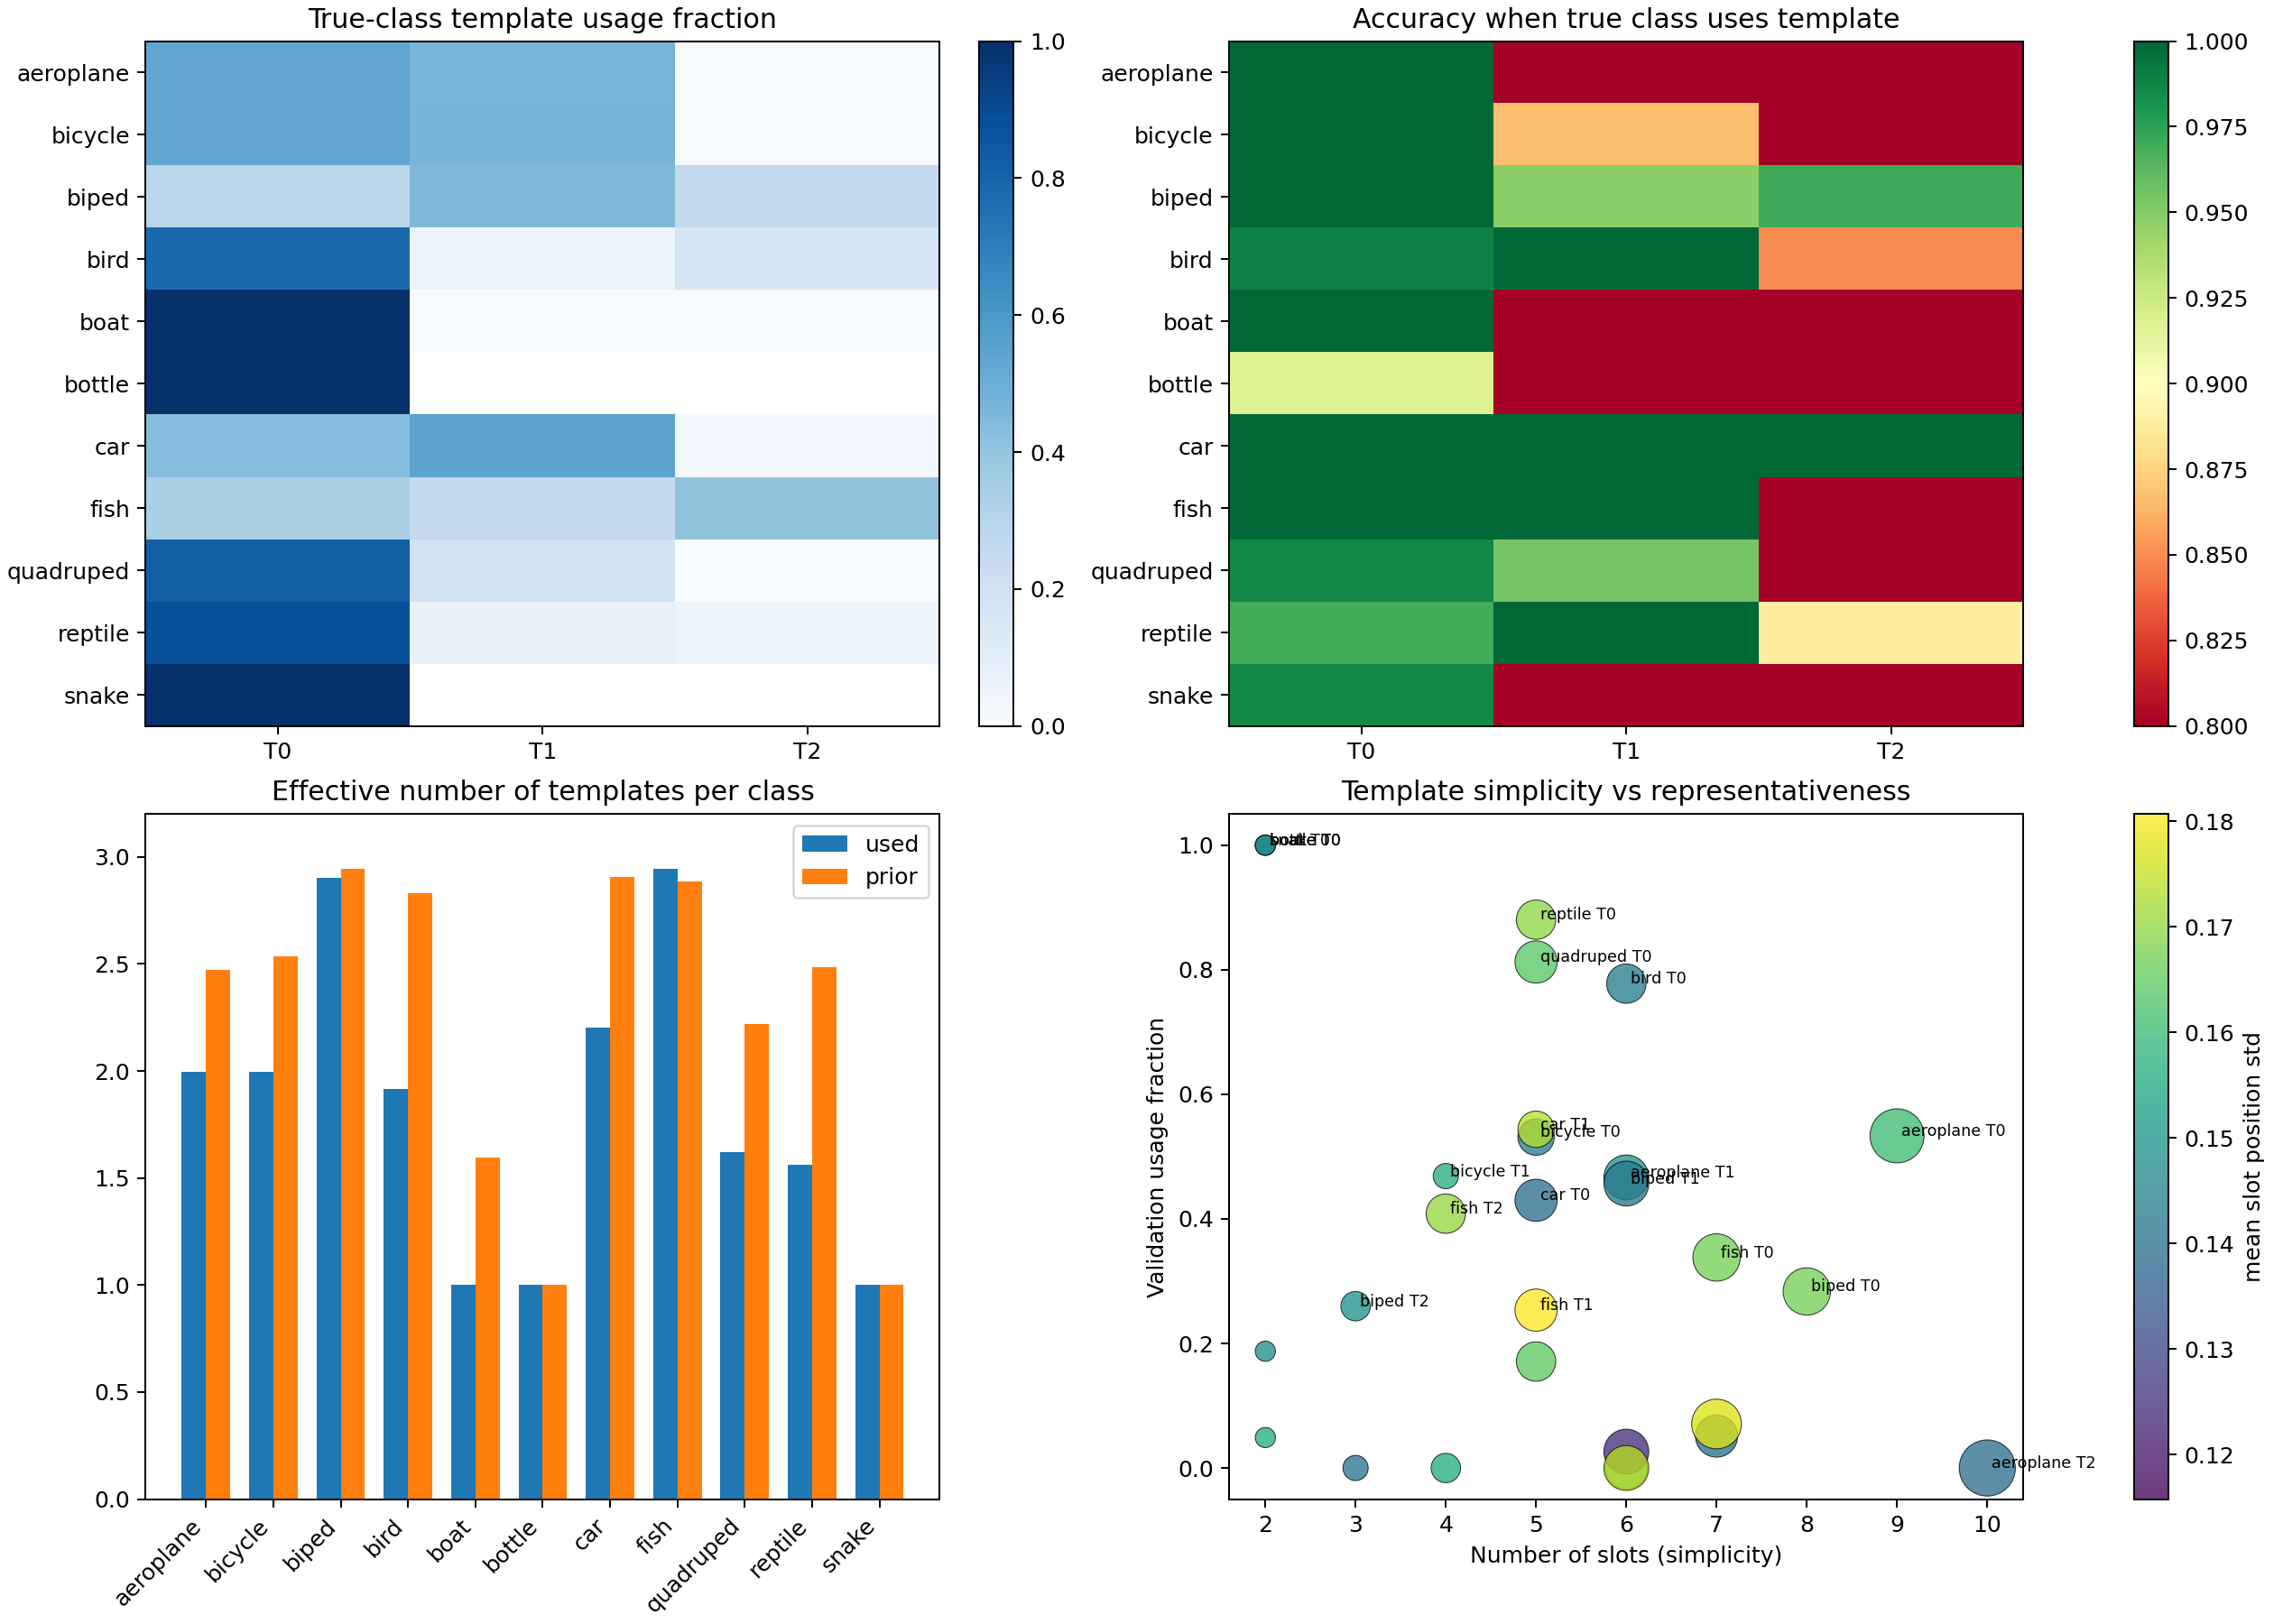

### v39 simplicity/flexibility scatter

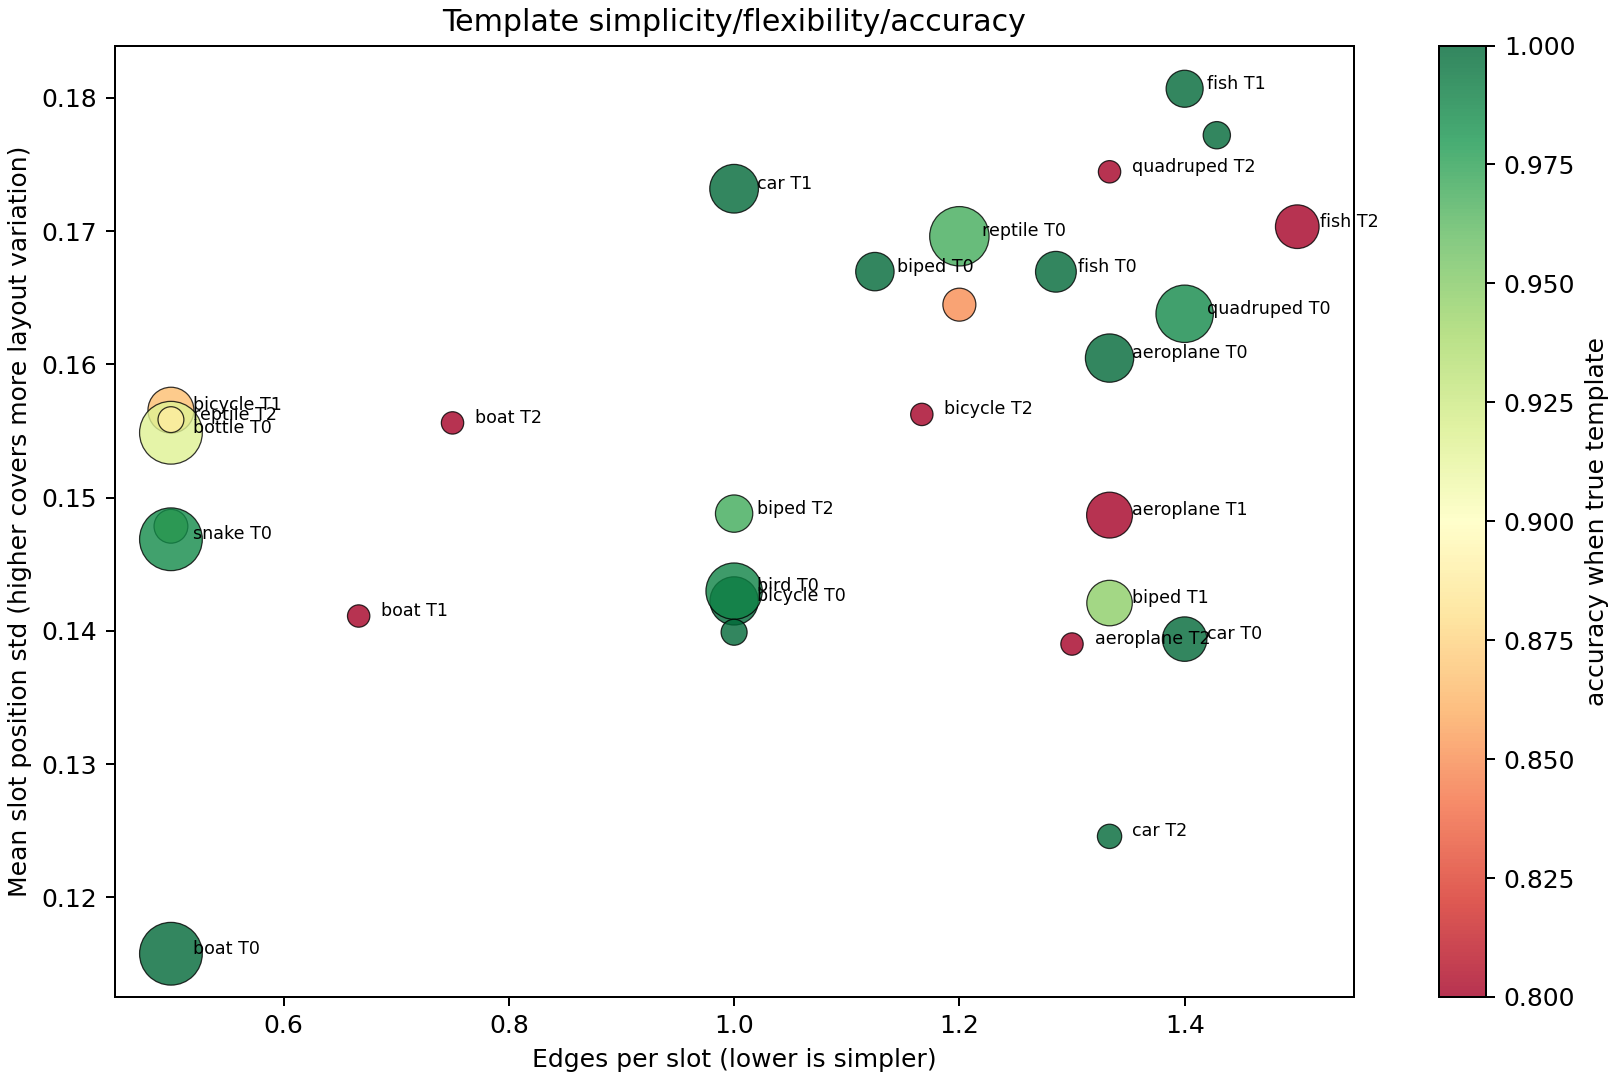

### v38 dashboard

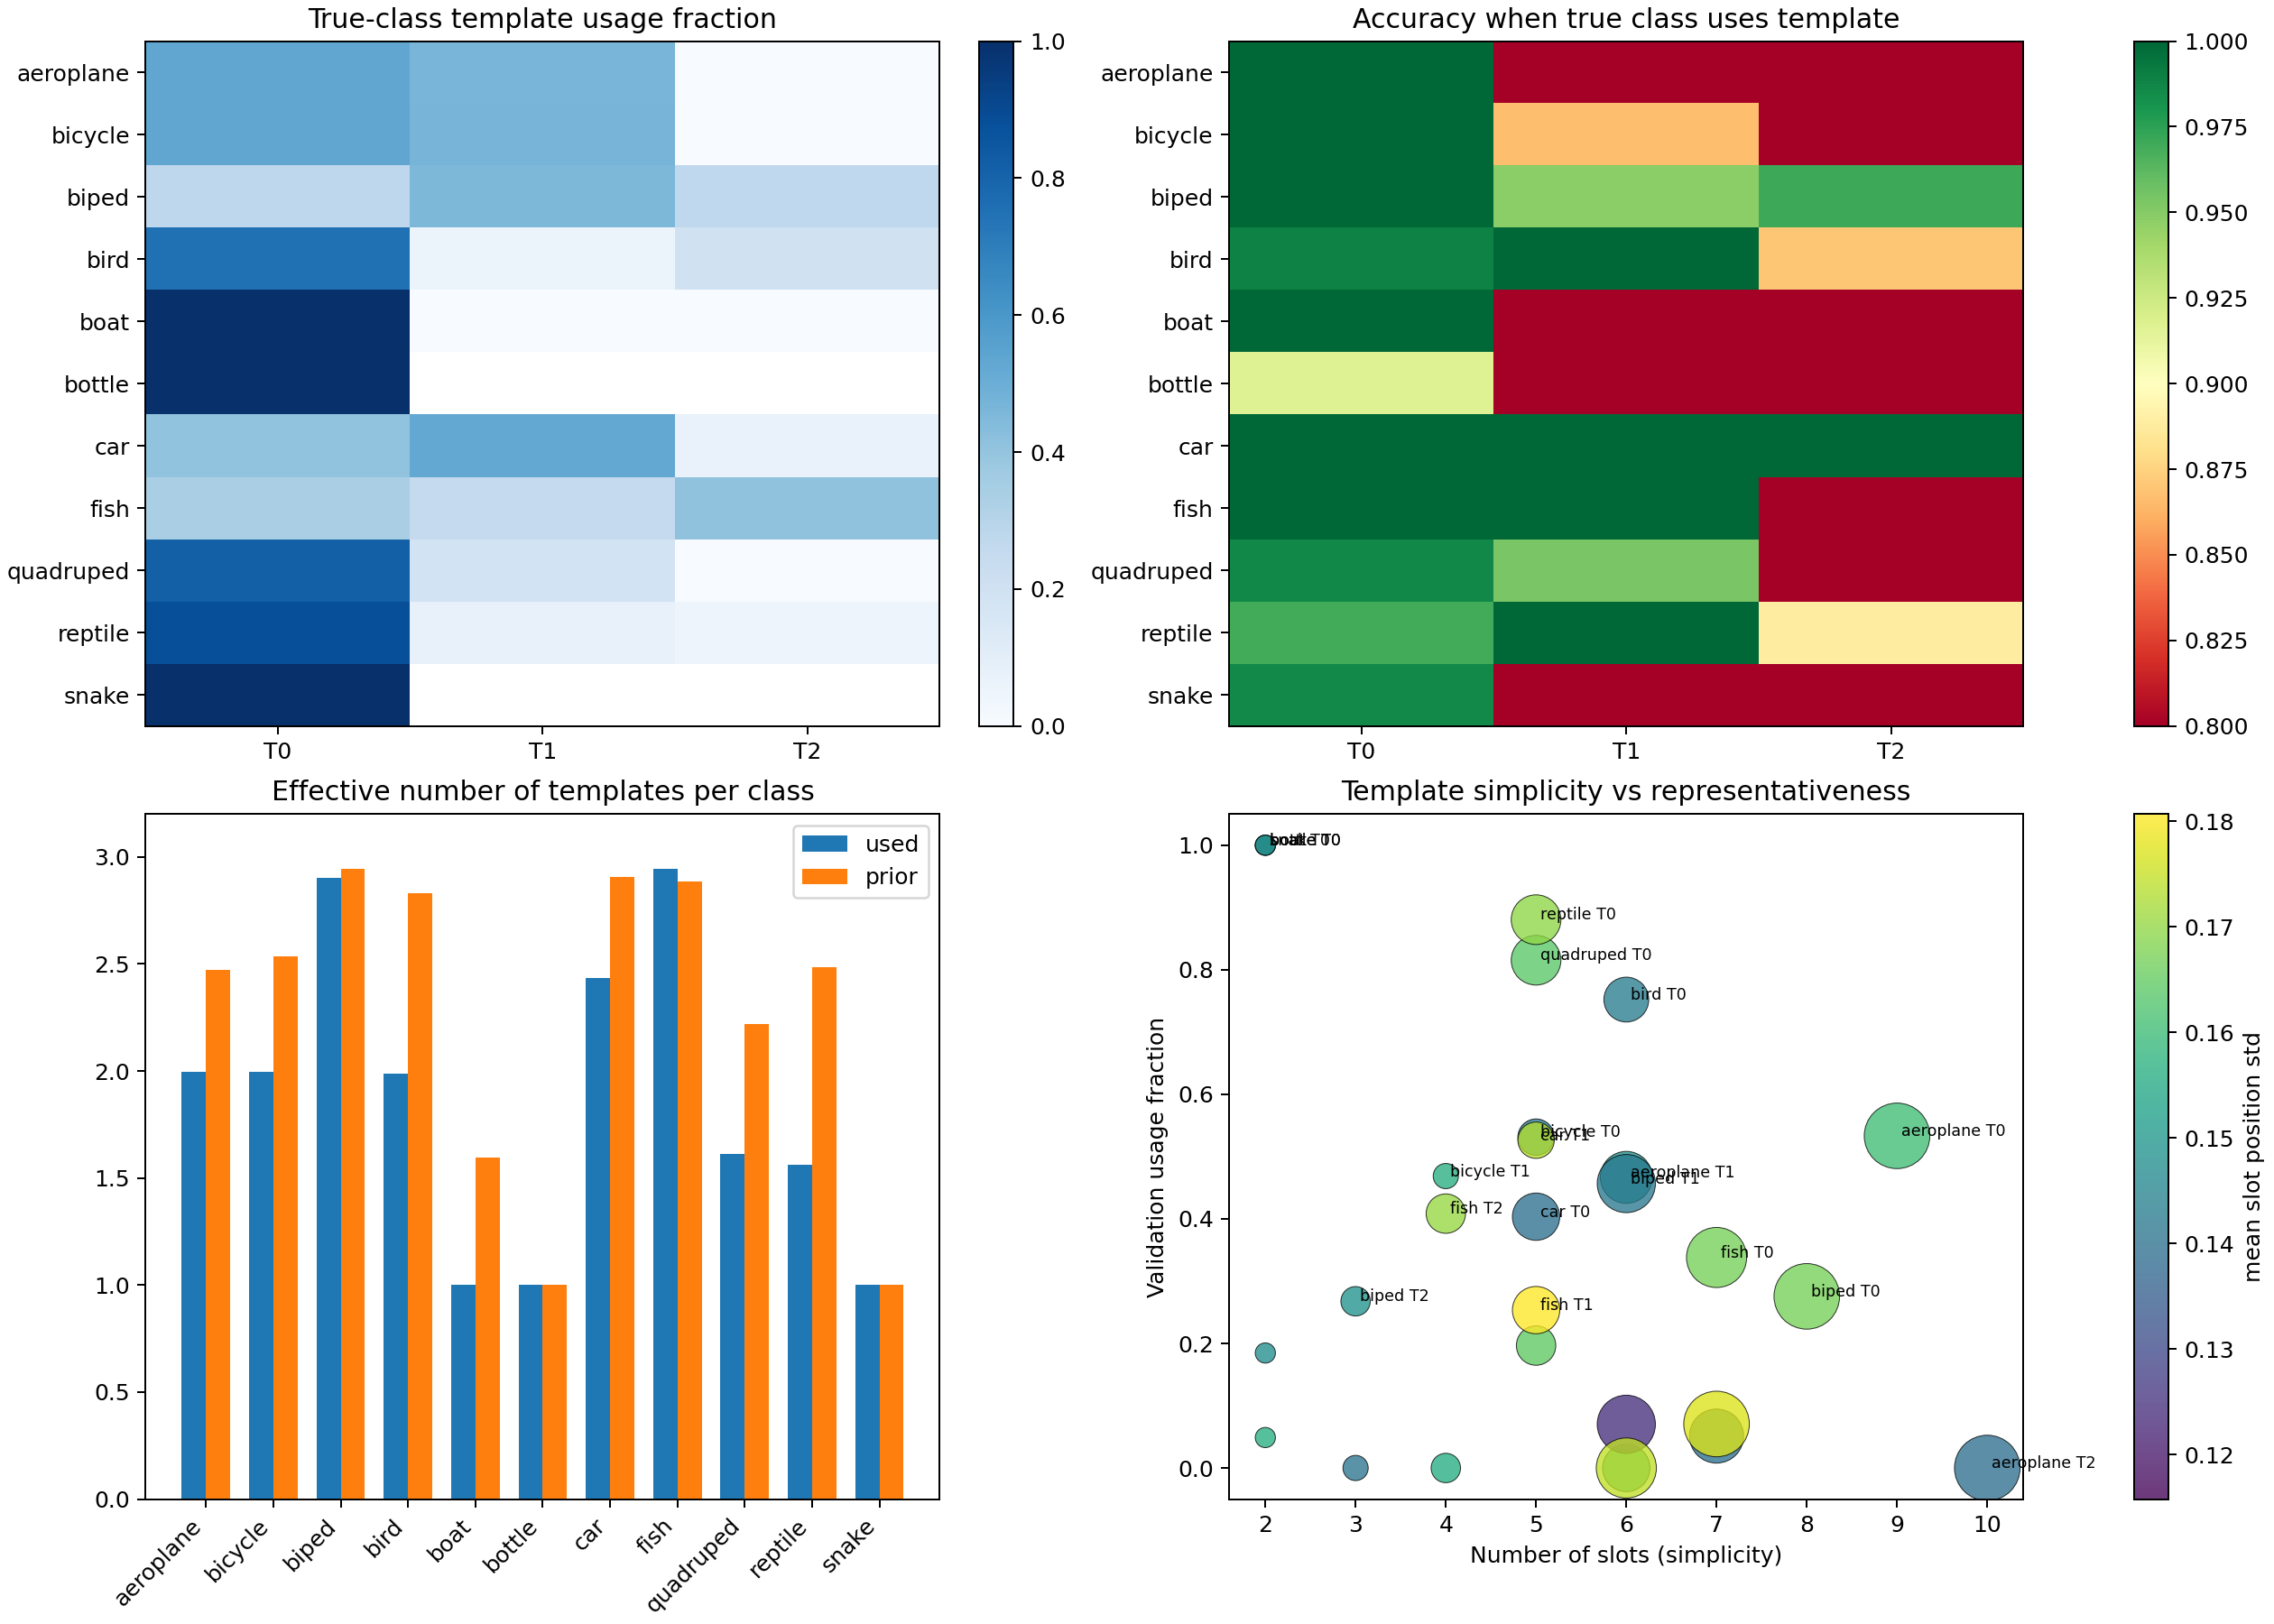

### v38 simplicity/flexibility scatter

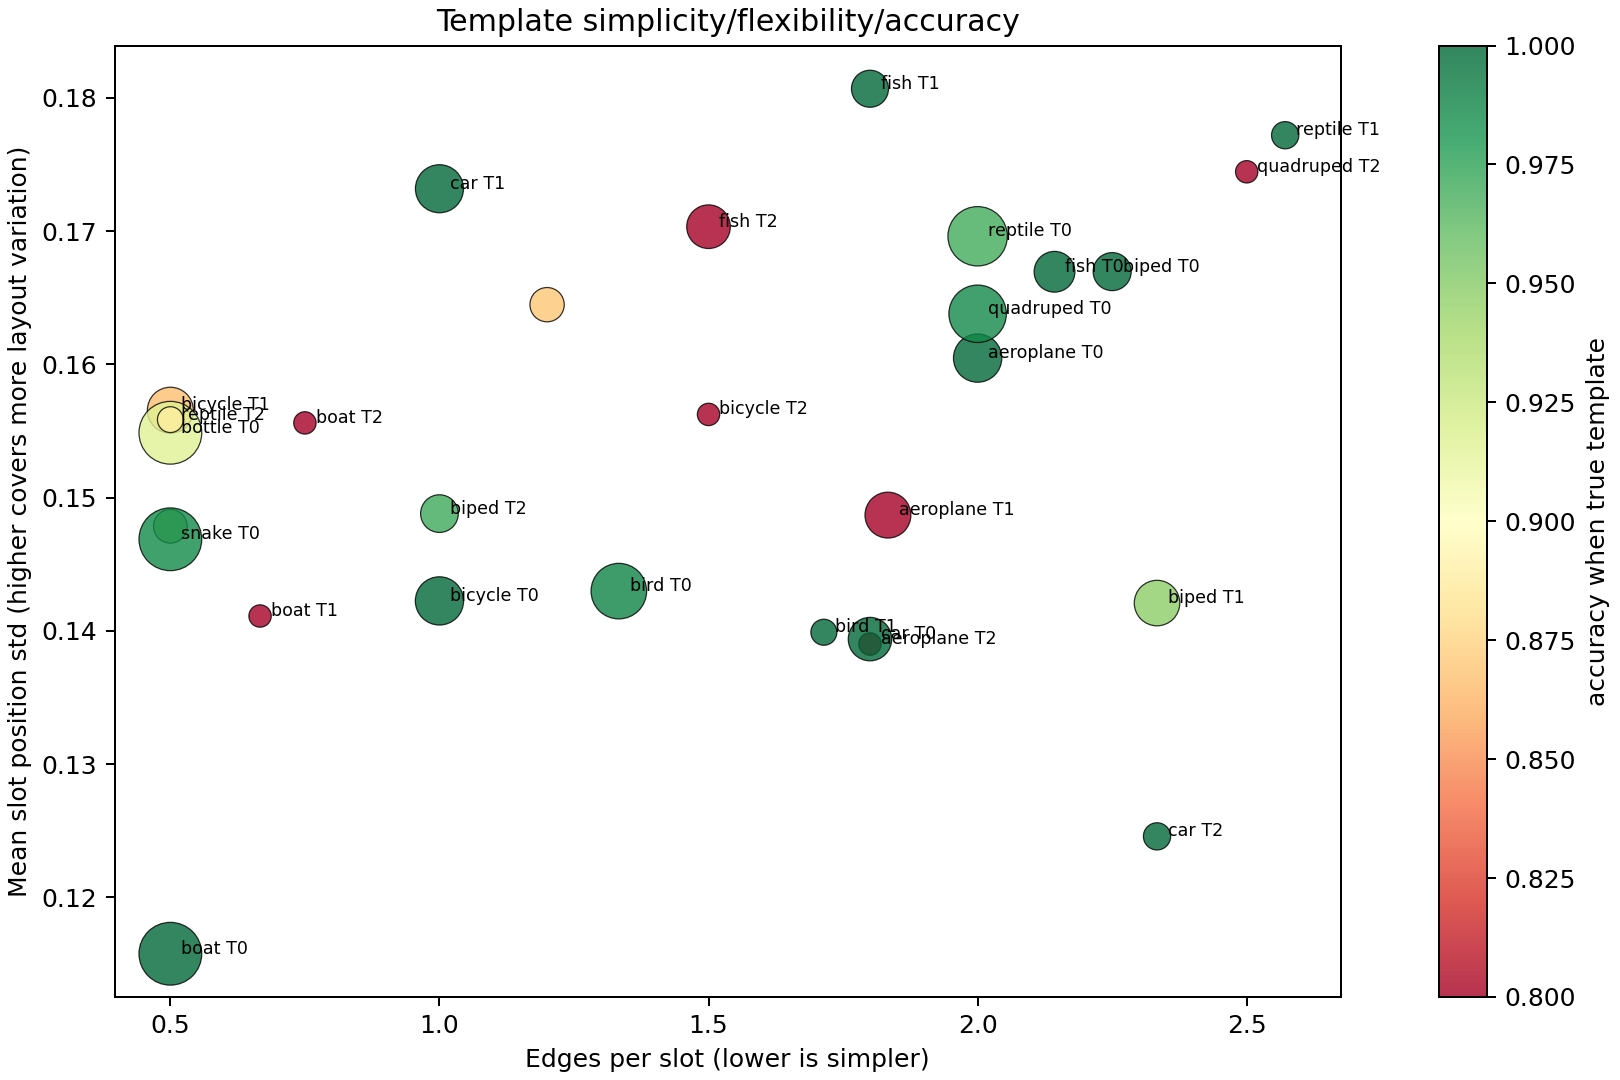

In [4]:
display(Markdown('### v39 dashboard'))
display(Image(filename=str(V39 / 'strict_aog_v39_template_quality_dashboard.png')))
display(Markdown('### v39 simplicity/flexibility scatter'))
display(Image(filename=str(V39 / 'strict_aog_v39_simplicity_flexibility_scatter.png')))
display(Markdown('### v38 dashboard'))
display(Image(filename=str(V38 / 'strict_aog_v38_template_quality_dashboard.png')))
display(Markdown('### v38 simplicity/flexibility scatter'))
display(Image(filename=str(V38 / 'strict_aog_v38_simplicity_flexibility_scatter.png')))

## Current Interpretation

The old audit was structural only. The new diagnostics show v39 is simpler than v38 in edge complexity and removes high-degree templates, but it still has representativeness problems: several low-use alternatives and a high-use complex aeroplane template. That suggests the next design should not merely reduce edges; it should simplify slot definitions and make template alternatives cover distinct layout modes.
